### Example 3: Marmousi velocity model

We calculate the total field described by the Helmholtz equation. A 5-Hz time-harmonic point source is located at $[5000, -500]$ m within the modified Marmousi velocity model $[0, 9980] \times [-3460, 0] \text{ m}^2$. The grid size is $h = 20$ m in both $x$- and $y$-directions.

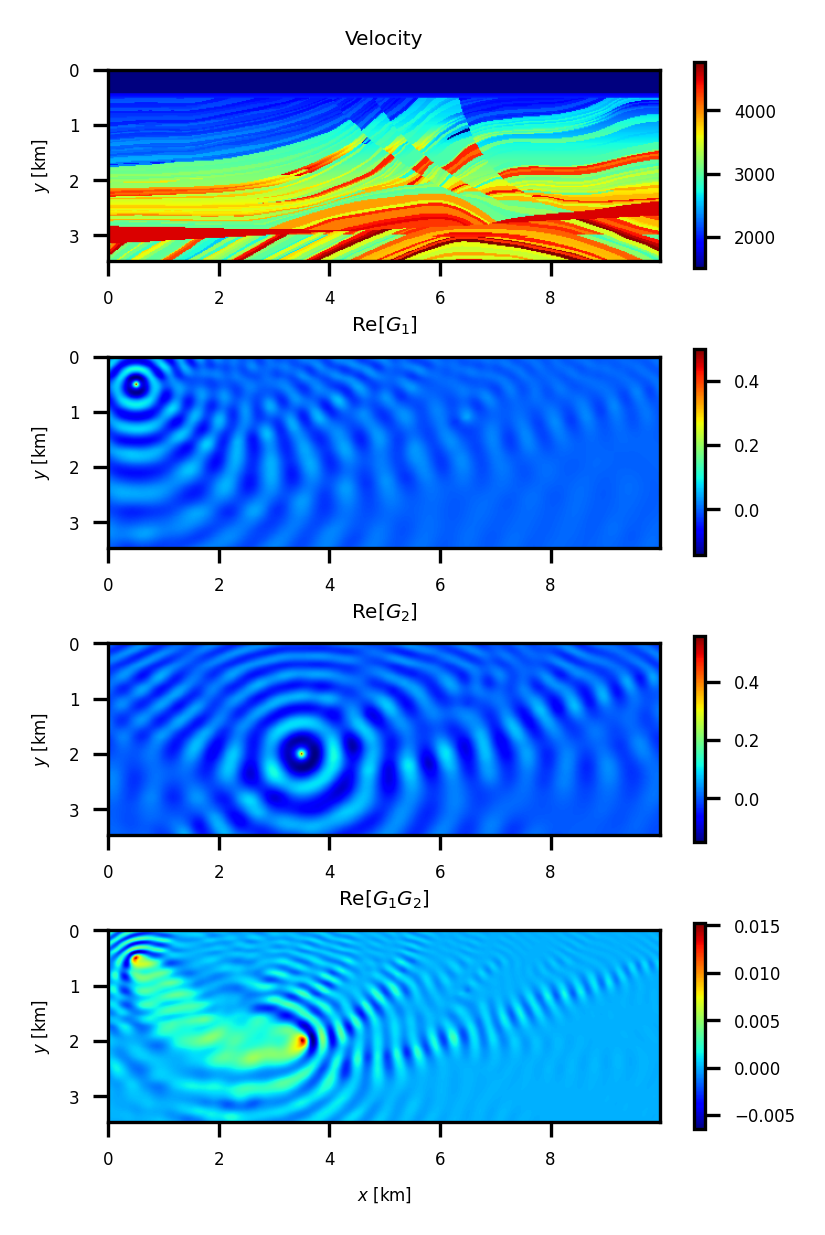

In [7]:
import numpy as np
from matplotlib.pyplot import *
import pyhelmholtz as ph

h = 20.
velocity = np.load("2d_marmousi_vp.npy")
domain = ph.Domain(h=h, v=velocity, positive_downward=True)
s1 = ph.PointSource(freq=5., xs=500, ys=500)
hs1 = ph.HelmholtzSolver(domain=domain, source=s1, abm=ph.HEM2(n=10))
hs1.solve()
G1 = hs1.u
s2 = ph.PointSource(freq=5., xs=3500, ys=2000)
hs2 = ph.HelmholtzSolver(domain=domain, source=s2, abm=ph.HEM2(n=10))
hs2.solve()
G2 = hs2.u
rcParams['font.size'] = 4
figure(figsize=(2.7,4),dpi=300)
subplot(411);hs1.viz(data="velocity", unit="km", xlabel=False)
subplot(412);hs1.viz(data="solution", unit="km", title="Re[$G_1$]", xlabel=False)
subplot(413);hs2.viz(data="solution", unit="km", title="Re[$G_2$]", xlabel=False)
subplot(414);hs1.viz(data=G1*G2, unit="km", title="Re[$G_1G_2$]")
gcf().tight_layout()